<a href="https://colab.research.google.com/github/mayowaawo/Deep-Learning-/blob/main/HW2_CNN_image_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Convolutional Neural Networks

#### Setting up your Development Environment

You can install dependencies from within a Jupyter notebook using Python's pip package manager with the magic command `%` (or `!`):
```python
%pip install torch torchvision torchinfo numpy matplotlib scikit-learn medmnist
```

If the magic command fails, try the below instead:
```python
import sys
!{sys.executable} -m pip install torch torchvision torchinfo numpy matplotlib scikit-learn medmnist
```

You can use uv to create a virtual environment to manage your dependencies, and to install your dependencies/packages into that virtual environment:
```zsh
$ uv venv
$ source <path-to-activation-script>
(mydir) $ uv pip install torch torchvision torchinfo numpy matplotlib scikit-learn medmnist
```

You can use uv to run JupyterLab; make sure you do so with the virtual environment activated:
```zsh
(mydir) $ uv run --with jupyter jupyter lab
```

If you'd like to use your uv virtual environment as the kernel for a Jupyter environment in VS Code, the following may be helpful:
```zsh
(mydir) $
(mydir) $ uv pip install ipykernel
(mydir) $ uv run ipython kernel install --user --env VIRTUAL_ENV $(pwd)/.venv --name=cnn
```

If you're connecting to JupyterLab over ssh, for example to JupyterLab running on one of the Lab workstations, you can set up an ssh tunnel with the following:
```zsh
$ ssh -i ~/.ssh/private_key_ed25519 -N -L 8888:localhost:8888 assignedusername@hfsl-hanlon2-29.fsc.stevens.edu
```

In [ ]:
# Uncomment the command below and run once to install dependencies; comment out the line again after running successfully.
%pip install torch torchvision torchinfo numpy matplotlib scikit-learn medmnist

# IPython setting so that we don't have to use print() all the time
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

# learning frameworks
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, Subset
import torchvision.transforms as transforms
from torchinfo import summary
from sklearn.metrics import classification_report

# for printing images
from matplotlib import pyplot as plt

# various math functions
import numpy as np
import pandas as pd

# VGG for HW2 demo
from torchvision import models

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 7.0 MB/s eta 0:00:00


In [ ]:
# import MedMNIST dataset

# from medmnist import PneumoniaMNIST
from medmnist import DermaMNIST

## Dataset: MedMNIST

MedMNIST is a large-scale MNIST-like collection of standardized biomedical images, including 12 datasets for 2D and 6 datasets for 3D. (For more info, visit <https://medmnist.com/>.)

In this tutorial, we'll use `PneumoniaMNIST`, a small image dataset for binary classification.

<img src='https://raw.githubusercontent.com/MedMNIST/MedMNIST/main/assets/medmnistv2.jpg'>

In [ ]:
# convert images to torch tensors
data_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[.5, .5, .5], std=[.5, .5, .5]) # Normalize pixel values for 3 channels
])

# load the data – each image is size 1 x 28 x 28 (grayscale)
train_dataset = DermaMNIST(split='train', transform = data_transform, download=True, size=28)
val_dataset = DermaMNIST(split='val',  transform=data_transform,  download=True, size=28)
test_dataset = DermaMNIST(split='test',  transform=data_transform, download=True, size=28)

In [ ]:
# check label distribution

# total number of training images
print(f"number of training images: {len(train_dataset)}")

# number of positive cases – label 1 indicates pneumonia/positive, label 0 indicates normal/negative
print(f"number of positive cases: {train_dataset.labels.sum().item()}")

number of training images: 7007
number of positive cases: 29312


In [ ]:
img, label = train_dataset[0]

print("image data:") # each [-0.2784, ... , -0.9765] is a row of normalized pixels; there are 28 such rows per channel [[...],...,[...]]; there is 1 channel per grayscale image [[[...],...,[...]]]
img

print("label:")
label[0].item()

image data:


tensor([[[ 0.2392,  0.2627,  0.2863,  ...,  0.4824,  0.4667,  0.4588],
         [ 0.2549,  0.2941,  0.3333,  ...,  0.4980,  0.4824,  0.4745],
         [ 0.2863,  0.3333,  0.3882,  ...,  0.4980,  0.4745,  0.4667],
         ...,
         [ 0.3490,  0.3804,  0.4275,  ...,  0.5294,  0.4196,  0.3412],
         [ 0.3804,  0.3804,  0.4118,  ...,  0.4745,  0.3961,  0.3412],
         [ 0.3725,  0.3569,  0.3647,  ...,  0.4118,  0.3725,  0.3569]],

        [[-0.1294, -0.0902, -0.0510,  ...,  0.2549,  0.2392,  0.2314],
         [-0.1137, -0.0588,  0.0118,  ...,  0.2706,  0.2549,  0.2471],
         [-0.0667,  0.0039,  0.0745,  ...,  0.2706,  0.2706,  0.2627],
         ...,
         [ 0.1137,  0.1529,  0.1765,  ...,  0.3098,  0.2000,  0.1216],
         [ 0.1529,  0.1529,  0.1608,  ...,  0.2549,  0.1765,  0.1216],
         [ 0.1451,  0.1294,  0.1137,  ...,  0.1922,  0.1529,  0.1373]],

        [[-0.0824, -0.0510,  0.0196,  ...,  0.2863,  0.2549,  0.2471],
         [-0.0667, -0.0196,  0.0745,  ...,  0

label:


0

In [ ]:
train_dataset
val_dataset
test_dataset

Dataset DermaMNIST of size 28 (dermamnist)
    Number of datapoints: 7007
    Root location: /root/.medmnist
    Split: train
    Task: multi-class
    Number of channels: 3
    Meaning of labels: {'0': 'actinic keratoses and intraepithelial carcinoma', '1': 'basal cell carcinoma', '2': 'benign keratosis-like lesions', '3': 'dermatofibroma', '4': 'melanoma', '5': 'melanocytic nevi', '6': 'vascular lesions'}
    Number of samples: {'train': 7007, 'val': 1003, 'test': 2005}
    Description: The DermaMNIST is based on the HAM10000, a large collection of multi-source dermatoscopic images of common pigmented skin lesions. The dataset consists of 10,015 dermatoscopic images categorized as 7 different diseases, formulized as a multi-class classification task. We split the images into training, validation and test set with a ratio of 7:1:2. The source images of 3×600×450 are resized into 3×28×28.
    License: CC BY-NC 4.0

Dataset DermaMNIST of size 28 (dermamnist)
    Number of datapoints: 1003
    Root location: /root/.medmnist
    Split: val
    Task: multi-class
    Number of channels: 3
    Meaning of labels: {'0': 'actinic keratoses and intraepithelial carcinoma', '1': 'basal cell carcinoma', '2': 'benign keratosis-like lesions', '3': 'dermatofibroma', '4': 'melanoma', '5': 'melanocytic nevi', '6': 'vascular lesions'}
    Number of samples: {'train': 7007, 'val': 1003, 'test': 2005}
    Description: The DermaMNIST is based on the HAM10000, a large collection of multi-source dermatoscopic images of common pigmented skin lesions. The dataset consists of 10,015 dermatoscopic images categorized as 7 different diseases, formulized as a multi-class classification task. We split the images into training, validation and test set with a ratio of 7:1:2. The source images of 3×600×450 are resized into 3×28×28.
    License: CC BY-NC 4.0

Dataset DermaMNIST of size 28 (dermamnist)
    Number of datapoints: 2005
    Root location: /root/.medmnist
    Split: test
    Task: multi-class
    Number of channels: 3
    Meaning of labels: {'0': 'actinic keratoses and intraepithelial carcinoma', '1': 'basal cell carcinoma', '2': 'benign keratosis-like lesions', '3': 'dermatofibroma', '4': 'melanoma', '5': 'melanocytic nevi', '6': 'vascular lesions'}
    Number of samples: {'train': 7007, 'val': 1003, 'test': 2005}
    Description: The DermaMNIST is based on the HAM10000, a large collection of multi-source dermatoscopic images of common pigmented skin lesions. The dataset consists of 10,015 dermatoscopic images categorized as 7 different diseases, formulized as a multi-class classification task. We split the images into training, validation and test set with a ratio of 7:1:2. The source images of 3×600×450 are resized into 3×28×28.
    License: CC BY-NC 4.0

In [ ]:
print("---number of images---")
print(f"training data: {len(train_dataset)}")
print(f"validation data: {len(val_dataset)}")
print(f"test data: {len(test_dataset)}")

---number of images---
training data: 7007
validation data: 1003
test data: 2005


In [ ]:
# reset to default to prevent extra output in cell below
InteractiveShell.ast_node_interactivity = "last_expr"

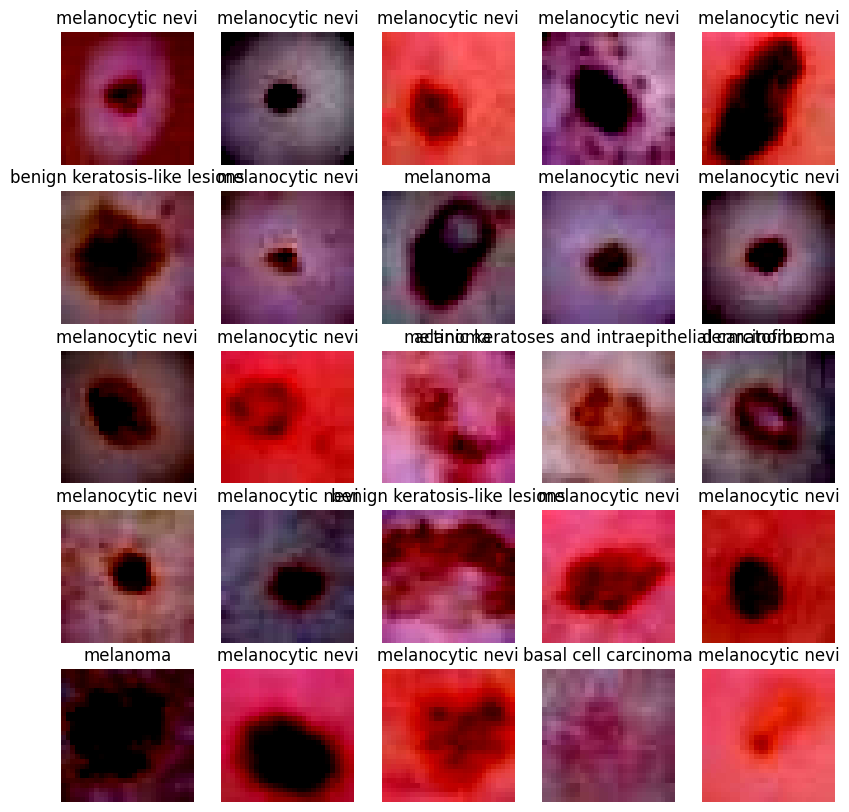

In [ ]:
figure = plt.figure(figsize=(10, 10))
cols, rows = 5, 5
for i in range(1, cols * rows + 1):
    sample_idx = torch.randint(len(train_dataset), size=(1,)).item()
    img, label = train_dataset[sample_idx]

    figure.add_subplot(rows, cols, i)
    # Map numerical label to string label for better readability
    plt.title(train_dataset.info['label'][str(label[0].item())]) # Convert integer label to string
    plt.axis("off")
    # Remove cmap="gray" as images are 3-channel (RGB)
    plt.imshow(img.permute(1, 2, 0).numpy()) # Permute to (H, W, C) for matplotlib
plt.show()

In [ ]:
InteractiveShell.ast_node_interactivity = "all"

In [ ]:
# DataLoaders

batch_size = 128

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [ ]:
class SimpleConvnet(nn.Module):
    def __init__(self, input_channels = 1,  output_size = 1):
        super(SimpleConvnet, self).__init__()
        print(f"Initializing SimpleConvnet with input_channels={input_channels}") # Debug print

        # convnet structure
        self.convnet = nn.Sequential( # input (num_batch, 1, 28, 28)
            nn.Conv2d(in_channels=input_channels, out_channels=32, kernel_size=3), # (num_batch, 32, 26, 26); by default stride = 1
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2), # (num_batch, 32, 13, 13); if stride is not provided, it will default to kernel_size

            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=2), # (num_batch, 64, 12, 12); by default stride = 1
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2), # (num_batch, 64, 6, 6); if stride is not provided, it will default to kernel_size

            nn.Conv2d(in_channels=64, out_channels=24, kernel_size=2), # (num_batch, 24, 5, 5)
            nn.BatchNorm2d(24),
            nn.ReLU(),
            nn.Flatten()
        )

        # classifier
        self.classifier = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(in_features=24*5*5, out_features=64),
            nn.ReLU(),
            nn.Linear(in_features=64, out_features=output_size)
        )

    def forward(self, x):
        x = self.convnet(x)
        x = self.classifier(x)

        return x

In [ ]:
batch_size = 128
num_classes = len(train_dataset.info['label'])
simplemodel = SimpleConvnet(input_channels = 3, output_size = num_classes)
summary(simplemodel, (batch_size, 3, 28, 28))

Layer (type:depth-idx)                   Output Shape              Param #
SimpleConvnet                            [128, 7]                  --
├─Sequential: 1-1                        [128, 600]                --
│    └─Conv2d: 2-1                       [128, 32, 26, 26]         896
│    └─BatchNorm2d: 2-2                  [128, 32, 26, 26]         64
│    └─ReLU: 2-3                         [128, 32, 26, 26]         --
│    └─MaxPool2d: 2-4                    [128, 32, 13, 13]         --
│    └─Conv2d: 2-5                       [128, 64, 12, 12]         8,256
│    └─BatchNorm2d: 2-6                  [128, 64, 12, 12]         128
│    └─ReLU: 2-7                         [128, 64, 12, 12]         --
│    └─MaxPool2d: 2-8                    [128, 64, 6, 6]           --
│    └─Conv2d: 2-9                       [128, 24, 5, 5]           6,168
│    └─BatchNorm2d: 2-10                 [128, 24, 5, 5]           48
│    └─ReLU: 2-11                        [128, 24, 5, 5]           --
│    └─

In [ ]:
def test(model, test_dataloader, print_report=True):

    # Set the model to evaluation mode
    model.eval()

    # No need to track gradients during evaluation
    with torch.no_grad():
        ys_hat = []       # placehoders for predictions
        ys = []           # placeholders for actual values of y
        eval_loss = []    # placeholder for loss

        for batch_X, batch_y in test_dataloader:

            batch_X = batch_X.to(device)
            batch_y = batch_y.to(device)

            # forward pass
            outputs = model(batch_X)   # The model output shape is (N, C).
            loss = criterion(outputs, batch_y.squeeze())  # Calculate the loss for multi-class

            preds = torch.argmax(outputs, dim=1)
            ys_hat.append(preds.cpu().numpy()) # move output out of gpu and record it in the placeholder
            ys.append(batch_y.cpu().numpy()) # move actual y out of gpu and record it in the placeholder
            eval_loss.append(loss.item()) # log loss

        # After testing all samples, compute the average loss and acc

        eval_loss = np.mean(eval_loss)

        # Concatenate ys_hat and ys into arrays
        ys_hat = np.concatenate(ys_hat)
        ys = np.concatenate(ys)

        # Get accuracy
        eval_acc = (ys_hat == ys).mean()

    print(f'Test Loss: {eval_loss:.4f}, Test Accuracy: {eval_acc:.4f}\n')

    # Also print out classification report of precision, recall, F1
    if print_report:
        print(classification_report(ys, ys_hat))

    return eval_acc, eval_loss

In [ ]:
def train_eval_early_stopping(model, train_dataloader, eval_dataloader, epochs=25, patience=5, model_save_path="best.pth"):

    train_loss = []   # placeholder for loss in each epoch
    train_acc = []    # placeholder for accuracy in each epoch

    eval_loss = []   # placeholder for loss in each epoch
    eval_acc = []    # placeholder for accuracy in each epoch

    best_loss = np.inf       # initial value of the best loss is infinite
    worse_cnt  = 0           # count how many times the model gets worse

    model.to(device)

    for epoch in range(epochs):

        model = model.train()  # Set the model to training mode

        # Move data to device
        batch_loss = []    # placeholder for loss in each batch
        batch_acc = []    # placeholder for accuracy in each batch

        for batch_X, batch_y in train_dataloader:


            # Move data to device
            batch_X = batch_X.to(device)
            batch_y = batch_y.to(device)

            # Forward pass: Compute predicted y by passing x to the model
            outputs = model(batch_X)   # The model output shape is (N, C).

            # We'll use CrossEntropyLoss, which expects target to be long integers
            loss = criterion(outputs, batch_y.squeeze())  # Calculate the loss

            preds = torch.argmax(outputs, dim=1)
            acc = (preds == batch_y).float().mean().item()
            batch_acc.append(acc)

            # Backward pass: Compute gradients and update weights
            optimizer.zero_grad()  # Zero the gradients
            loss.backward()        # Backpropagation
            optimizer.step()       # Update the weights

            # log loss
            batch_loss.append(loss.item())

        # After completing an epoch, let's calculate average loss and accuracy and log them to train_loss and train_acc

        epoch_loss = np.array(batch_loss).mean()
        epoch_acc = np.array(batch_acc).mean()

        train_loss.append(epoch_loss)
        train_acc.append(epoch_acc)

        print(f'Epoch [{epoch+1}/{epochs}], Loss: {epoch_loss:.4f}, Accuracy: {epoch_acc:.4f}')

        # Let's evaluate the model after each epoch
        # We can reuse the test function with eval_dataloader as input
        # Let's don't print out the classification report
        acc, loss = test(model, eval_dataloader, print_report = False)

        # Accumulate evaluation loss and accuarcy
        eval_loss.append(loss)
        eval_acc.append(acc)

        # Implementing early stopping
        if loss < best_loss:
            best_loss = loss
            worse_cnt  = 0
            torch.save(model.state_dict(), model_save_path )
            print("best model saved\n")
        else:
            worse_cnt += 1
            if worse_cnt >= patience:
                print("early stopping\n")
                model.load_state_dict(torch.load(model_save_path ))
                break

    return train_loss, train_acc, eval_loss, eval_acc

In [ ]:
def plot_curves(epochs, loss_list, acc_list, name_list):

    # epochs: the number of epochs
    # loss_list: multiple lists of loss values
    # acc_list: multiple lists of accuracy values
    # name_list: the name for each list for plot legend

    # Create a figure and a set of subplots
    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10,4))

    # Plot on the loss subplot
    for name, loss in zip(name_list, loss_list):
        axes[0].plot(range(epochs), np.array(loss), label = name)
    axes[0].set_ylabel("Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_title('Training loss')
    axes[0].legend()

    # Plot on the accuracy subplot
    for name, acc in zip(name_list, acc_list):
        axes[1].plot(range(epochs), np.array(acc), label = name)
    axes[1].set_ylabel("Acc")
    axes[1].set_xlabel("Epoch")
    axes[1].set_title('Training Accuracy')
    axes[1].legend()

    # Adjust layout to prevent overlapping
    plt.tight_layout()

    # Show the plot
    plt.show()

In [ ]:
# initialize the model, loss function, and optimizer

num_classes = len(train_dataset.info['label']) # Get the number of classes from the dataset info
model = SimpleConvnet(input_channels=3, output_size=num_classes)
criterion = nn.CrossEntropyLoss()  # for multi-class classification
optimizer = optim.Adam(model.parameters(), lr=0.0001)  # Adam optimizer
epochs = 25

device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
print(device)


cuda


Epoch [1/25], Loss: 1.4437, Accuracy: 0.5551
Test Loss: 1.0433, Test Accuracy: 0.6690

best model saved

Epoch [2/25], Loss: 0.9629, Accuracy: 0.6695
Test Loss: 0.8991, Test Accuracy: 0.6684

best model saved

Epoch [3/25], Loss: 0.8897, Accuracy: 0.6564
Test Loss: 0.8462, Test Accuracy: 0.6433

best model saved

Epoch [4/25], Loss: 0.8510, Accuracy: 0.6325
Test Loss: 0.8200, Test Accuracy: 0.6244

best model saved

Epoch [5/25], Loss: 0.8193, Accuracy: 0.6148
Test Loss: 0.7926, Test Accuracy: 0.6060

best model saved

Epoch [6/25], Loss: 0.8012, Accuracy: 0.6033
Test Loss: 0.7754, Test Accuracy: 0.6088

best model saved

Epoch [7/25], Loss: 0.7805, Accuracy: 0.5880
Test Loss: 0.7593, Test Accuracy: 0.5674

best model saved

Epoch [8/25], Loss: 0.7622, Accuracy: 0.5702
Test Loss: 0.7444, Test Accuracy: 0.5579

best model saved

Epoch [9/25], Loss: 0.7446, Accuracy: 0.5568
Test Loss: 0.7334, Test Accuracy: 0.5409

best model saved

Epoch [10/25], Loss: 0.7336, Accuracy: 0.5534
Test Loss

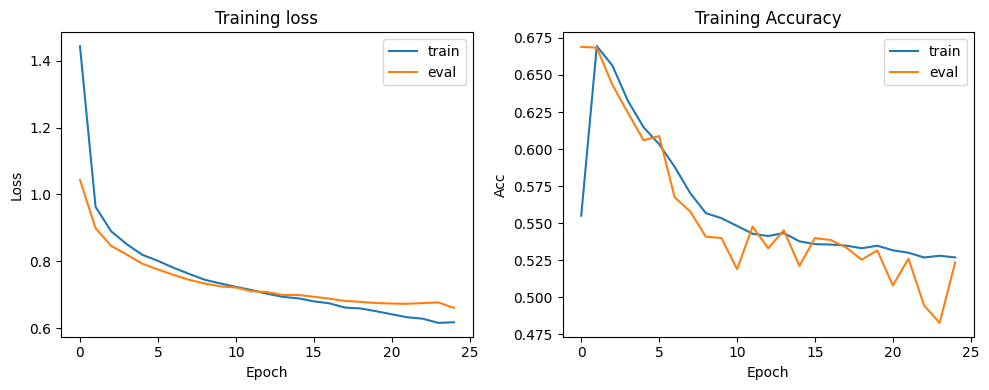

Test Loss: 0.6580, Test Accuracy: 0.5259

              precision    recall  f1-score   support

           0       0.54      0.32      0.40        66
           1       0.43      0.54      0.48       103
           2       0.56      0.45      0.50       220
           3       0.00      0.00      0.00        23
           4       0.54      0.33      0.41       223
           5       0.83      0.94      0.88      1341
           6       0.92      0.38      0.54        29

    accuracy                           0.76      2005
   macro avg       0.54      0.42      0.46      2005
weighted avg       0.73      0.76      0.74      2005



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
train_loss, train_acc, eval_loss, eval_acc = train_eval_early_stopping(model, train_loader, val_loader, epochs=epochs)
plot_curves(len(train_loss), [train_loss, eval_loss], [train_acc, eval_acc], ['train', 'eval'])
test_acc, test_loss = test(model, test_loader)